# 03 — Baseline results

Reads `results/metrics/summary.parquet` produced by `experiments/run.py`
and renders comparison plots. To regenerate numbers:

```bash
for cfg in experiments/configs/baseline_*.yaml; do
  python -m experiments.run $cfg
done
```


In [1]:
import sys; from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import METRICS_DIR, save_figure
sns.set_theme(style='whitegrid', context='notebook')


In [2]:
df = pd.read_parquet(METRICS_DIR / 'summary.parquet')
print('rows:', len(df), 'configs:', df['run_name'].nunique())
df.head()


rows: 69 configs: 11


,run_name,config_hash,dataset,model,seed,threshold,threshold_method,fit_seconds,n_train,n_test,test_attack_rate,metric,precision,recall,f1,roc_auc,pr_auc,tap,tar,etapr_f1
0,baseline_morris_isolation_forest,dd04e244f6d5,morris,isolation_forest,42,0.142913,val_percentile,1.719591,84274,89136,0.484305,pointwise,0.850880,0.066089,0.122652,0.663407,0.613398,NaN,NaN,NaN
1,baseline_morris_isolation_forest,dd04e244f6d5,morris,isolation_forest,42,0.142913,val_percentile,1.719591,84274,89136,0.484305,point_adjust,0.953135,0.235563,0.377763,NaN,NaN,NaN,NaN,NaN
2,baseline_morris_isolation_forest,dd04e244f6d5,morris,isolation_forest,42,0.142913,val_percentile,1.719591,84274,89136,0.484305,etapr,NaN,NaN,NaN,NaN,NaN,0.864915,0.115263,0.203417
3,baseline_morris_isolation_forest,dd04e244f6d5,morris,isolation_forest,7,0.142416,val_percentile,0.778109,84274,89136,0.484305,pointwise,0.761257,0.037596,0.071654,0.656002,0.600262,NaN,NaN,NaN
4,baseline_morris_isolation_forest,dd04e244f6d5,morris,isolation_forest,7,0.142416,val_percentile,0.778109,84274,89136,0.484305,point_adjust,0.921680,0.138757,0.241202,NaN,NaN,NaN,NaN,NaN


In [3]:
# F1 per model × dataset × metric, averaged over seeds.
agg = (df.groupby(['dataset', 'model', 'metric'])
         .agg(f1_mean=('f1', 'mean'), f1_std=('f1', 'std'), etapr_mean=('etapr_f1', 'mean'))
         .reset_index())
# For eTaPR rows, pick the etapr_f1 column into the f1 field.
agg.loc[agg['metric'] == 'etapr', 'f1_mean'] = agg.loc[agg['metric'] == 'etapr', 'etapr_mean']
agg[['dataset', 'model', 'metric', 'f1_mean', 'f1_std']]


,dataset,model,metric,f1_mean,f1_std
0,hai,dense_ae,etapr,0.057214,NaN
1,hai,dense_ae,point_adjust,0.476732,NaN
2,hai,dense_ae,pointwise,0.355598,NaN
3,hai,isolation_forest,etapr,0.242739,NaN
4,hai,isolation_forest,point_adjust,0.621107,0.031578
5,hai,isolation_forest,pointwise,0.184802,0.036456
6,hai,lstm_ae,etapr,0.146948,NaN
7,hai,lstm_ae,point_adjust,0.221005,NaN
8,hai,lstm_ae,pointwise,0.105010,NaN
9,hai,ocsvm,etapr,0.170112,NaN


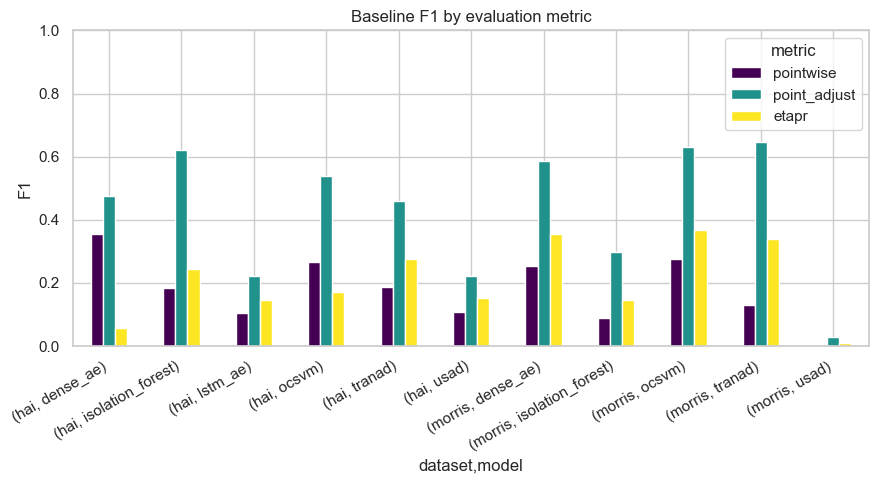

In [4]:
# Headline chart: F1 by metric, grouped by (dataset, model).
plot_df = agg.pivot_table(index=['dataset', 'model'], columns='metric', values='f1_mean')
plot_df = plot_df.reindex(columns=['pointwise', 'point_adjust', 'etapr'])
fig, ax = plt.subplots(figsize=(9, 5))
plot_df.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_ylabel('F1')
ax.set_ylim(0, 1)
ax.set_title('Baseline F1 by evaluation metric')
ax.legend(title='metric')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
save_figure(fig, 'baseline_f1_by_metric', subdir='03_baseline')
plt.show()


## Markdown-ready table

In [5]:
print(plot_df.round(3).to_markdown())


|                                |   pointwise |   point_adjust |   etapr |
|:-------------------------------|------------:|---------------:|--------:|
| ('hai', 'dense_ae')            |       0.356 |          0.477 |   0.057 |
| ('hai', 'isolation_forest')    |       0.185 |          0.621 |   0.243 |
| ('hai', 'lstm_ae')             |       0.105 |          0.221 |   0.147 |
| ('hai', 'ocsvm')               |       0.265 |          0.54  |   0.17  |
| ('hai', 'tranad')              |       0.189 |          0.458 |   0.276 |
| ('hai', 'usad')                |       0.107 |          0.222 |   0.151 |
| ('morris', 'dense_ae')         |       0.253 |          0.586 |   0.356 |
| ('morris', 'isolation_forest') |       0.09  |          0.297 |   0.145 |
| ('morris', 'ocsvm')            |       0.275 |          0.631 |   0.369 |
| ('morris', 'tranad')           |       0.129 |          0.647 |   0.339 |
| ('morris', 'usad')             |       0.001 |          0.03  |   0.009 |
